## Wildfire Prediction Models
Khushi Khan, Ella Chee, Willbert Clement Christianto  
DS4420

In [ ]:
from utils import split_to_matrices, plot_img
from pathlib import Path
from PIL import ImageFile
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# keras contains the tensorflow package, often used for fitting NNets
import keras
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Dense, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten
from keras.optimizers import SGD
from keras.losses import binary_crossentropy

In [8]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

data_root = Path("../data/raw")
classes = ["wildfire", "nowildfire"]
img_dim = (224, 244)
num_channels = 3

In [3]:
# Already MinMax
X_train, y_train = split_to_matrices(data_root / "train", img_dim, classes)
X_test, y_test = split_to_matrices(data_root / "test", img_dim, classes)
X_valid, y_valid = split_to_matrices(data_root / "valid", img_dim, classes)

In [4]:
print(f"Total number of images in X_train: {X_train.shape[0]}\nImage dimensions in X_train: {img_dim}\nImage channels: {X_train.shape[3]}")

Total number of images in X_train: 30250
Image dimensions in X_train: (224, 244)
Image channels: 3


There are 3 image channels because we're working with RGB images.

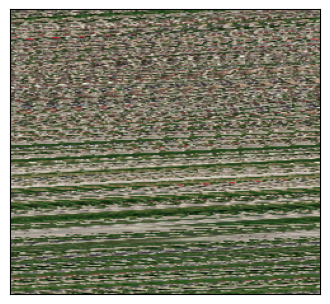

In [14]:
plot_img(X_test[X_test.shape[0]-1], im_shape=(img_dim[0], img_dim[1], num_channels))

In [ ]:
## TODO: figure out how to preserve coordinates of the image

In [18]:
# Building a CNN

# Instantiating a Keras tensor
inpx = Input(shape=(img_dim[0], img_dim[1], num_channels))

# Instantiating convolutional layer
conv_layer = Conv2D(1, kernel_size=(3,3), strides=1, activation=None)(inpx)

# Instantiating pooling layer
pool_layer = MaxPooling2D(pool_size=(3,3))(conv_layer)

# Flattening the images for the hidden layer/output
flat_G = Flatten()(conv_layer)

# Defining first hidden layer
hid_layer = Dense(250, activation='relu')(flat_G)

out_layer = Dense(1, activation='sigmoid')(hid_layer)

In [19]:
model = Model([inpx], out_layer)

model.compile(optimizer=SGD(),
              loss=binary_crossentropy,
              metrics=['accuracy'])

In [ ]:
model.fit(X_train, y_train, epochs=1)

In [ ]:
# Seems good, but check HOW good it is

preds = model.predict(X_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)
tbl = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(tbl)